# Project 2 — Image Compression with the SVD

## Objective

Use Singular Value Decomposition (SVD) to compress images by keeping only
the most important singular components.

We will compare images with different visual structures and study the
trade-off between storage and reconstruction quality.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

np.random.seed(42)


**R1 — Load and prepare (must have)**

At least three images, of genuinely different character:
- one smooth / low-detail (a sky, a portrait, a gradient)
- one high-detail / textured (foliage, a crowd, fabric, text)
- one of your choosing

Convert to greyscale as a 2-D float array. State the luminance weights
you used.

Report each image's shape and how many numbers it contains.
Images must be ones you are allowed to use. Your own photographs are ideal; otherwise state the source and licence.

In [4]:
# Load the three images

inspiration = Image.open("/content/Inspiration.jpeg")
kolkata = Image.open("/content/kolkata.jpeg")
Meri_photo = Image.open("/content/Meri photo.jpeg")

print("Inspiration:", inspiration.size)
print("Kolkata:", kolkata.size)
print("Meri_photo:", Meri_photo.size)

Inspiration: (1360, 915)
Kolkata: (1080, 987)
Meri_photo: (2250, 3000)


In [6]:
def load_grayscale(path):
    """
    convert images to grayscale,
    and return a 2-D floating-point array.
    """
    image = Image.open(path).convert("L")
    return np.asarray(image, dtype=np.float64)


inspiration_gray = load_grayscale("/content/Inspiration.jpeg")
kolkata_gray = load_grayscale("/content/kolkata.jpeg")
Meri_photo = load_grayscale("/content/Meri photo.jpeg")

print("Inspiration:", inspiration_gray.shape, inspiration_gray.dtype)
print("Kolkata:", kolkata_gray.shape, kolkata_gray.dtype)
print("Meri_photo:", Meri_photo.shape, Meri_photo.dtype)

Inspiration: (915, 1360) float64
Kolkata: (987, 1080) float64
Meri_photo: (3000, 2250) float64


The `Image.convert("L")` method in Pillow was used for grayscale conversion. This method uses the ITU-R 601-2 luma transform, with the following luminance weights:

L = R * 0.299 + G * 0.587 + B * 0.114

In [7]:
print(f"Inspiration gray image contains {inspiration_gray.shape[0] * inspiration_gray.shape[1]:,} numbers.")
print(f"Kolkata gray image contains {kolkata_gray.shape[0] * kolkata_gray.shape[1]:,} numbers.")
print(f"Meri photo gray image contains {Meri_photo.shape[0] * Meri_photo.shape[1]:,} numbers.")

Inspiration gray image contains 1,244,400 numbers.
Kolkata gray image contains 1,065,960 numbers.
Meri photo gray image contains 6,750,000 numbers.


## R2 — Decompose and reconstruct

- Compute the SVD with full_matrices=False.
- Reconstruct at a minimum of six values of k, including k = 1 and full rank.
- Verify that full-rank reconstruction returns the original to within floating-point tolerance. Print the check.
- Display a labelled grid: each reconstruction with its k and its compression ratio.

In [12]:
def svd_reconstruct_and_display(img_array, U, s, Vt, img_name):
    M, N = img_array.shape
    min_dim = min(M, N)

    # Determine k values, ensuring they are valid and distinct
    k_candidates = [1, 5, 10, 20, 50, min_dim // 2, min_dim]
    k_values = sorted(list(set([k for k in k_candidates if k <= min_dim])))

    # Ensure min_dim is always included if not already there, and sort again
    if min_dim not in k_values:
        k_values.append(min_dim)
        k_values = sorted(k_values)

    print(f"--- Processing {img_name} ---")
    print(f"Original image shape: {M}x{N}")
    print(f"Using k-values for reconstruction: {k_values}")

    reconstructions = []
    compression_ratios = []

    for k in k_values:
        # Reconstruct the image with rank k
        reconstructed_img = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
        reconstructions.append(reconstructed_img)

        # Calculate compression ratio
        # Original: M*N numbers
        # Compressed: M*k + k + k*N numbers
        compressed_size = M * k + k + k * N
        original_size = M * N
        compression_ratio = original_size / compressed_size
        compression_ratios.append(compression_ratio)

    # Verify full-rank reconstruction (last reconstruction in the list should be full rank)
    full_rank_recon = reconstructions[-1] # The last k_value is min_dim
    is_close = np.allclose(img_array, full_rank_recon)
    print(f"Verification for {img_name} (full rank vs original): {is_close}")

    # Display labelled grid
    num_plots = len(k_values) + 1  # Original + all reconstructions
    fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 5))
    fig.suptitle(f"SVD Reconstructions for {img_name}", fontsize=16)

    # Original Image
    axes[0].imshow(img_array, cmap='gray')
    axes[0].set_title("Original")
    axes[0].axis('off')

    # Reconstructed Images
    for i, k in enumerate(k_values):
        axes[i + 1].imshow(reconstructions[i], cmap='gray')
        axes[i + 1].set_title(f"k={k}\nRatio: {compression_ratios[i]:.2f}")
        axes[i + 1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()
    print("\n") # Add a newline for better separation between image outputs

--- Processing Inspiration ---
Original image shape: 915x1360
Using k-values for reconstruction: [1, 5, 10, 20, 50, 457, 915]
Verification for Inspiration (full rank vs original): True


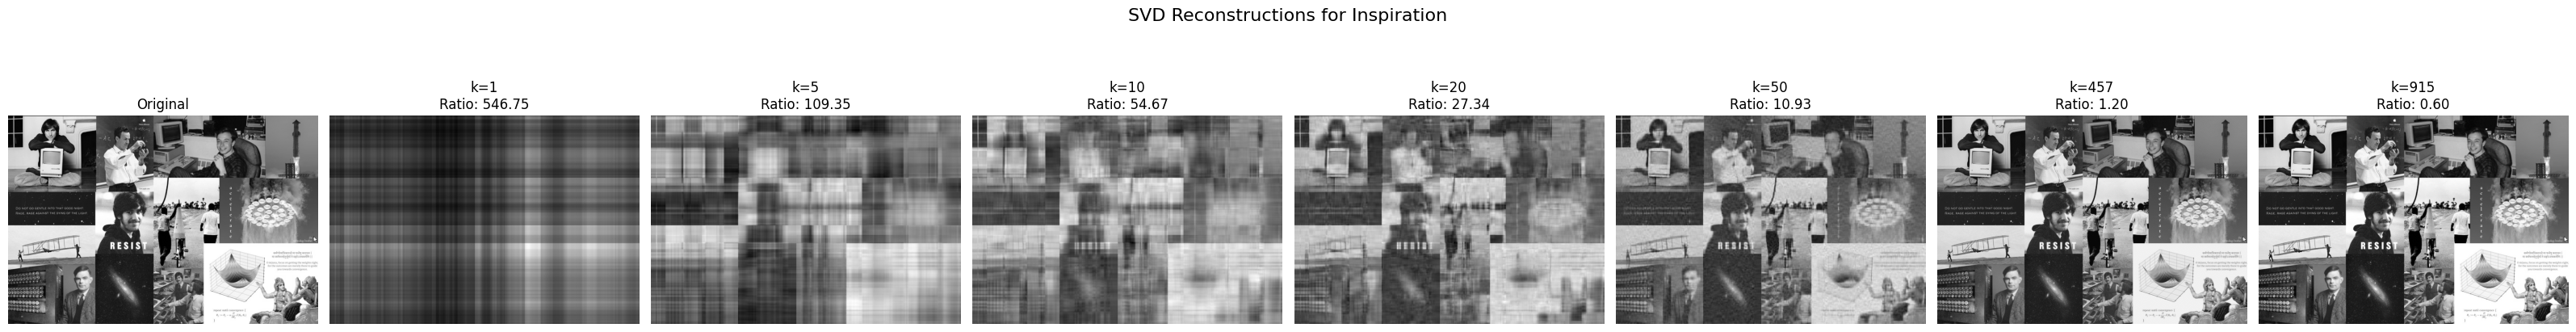



--- Processing Kolkata ---
Original image shape: 987x1080
Using k-values for reconstruction: [1, 5, 10, 20, 50, 493, 987]
Verification for Kolkata (full rank vs original): True


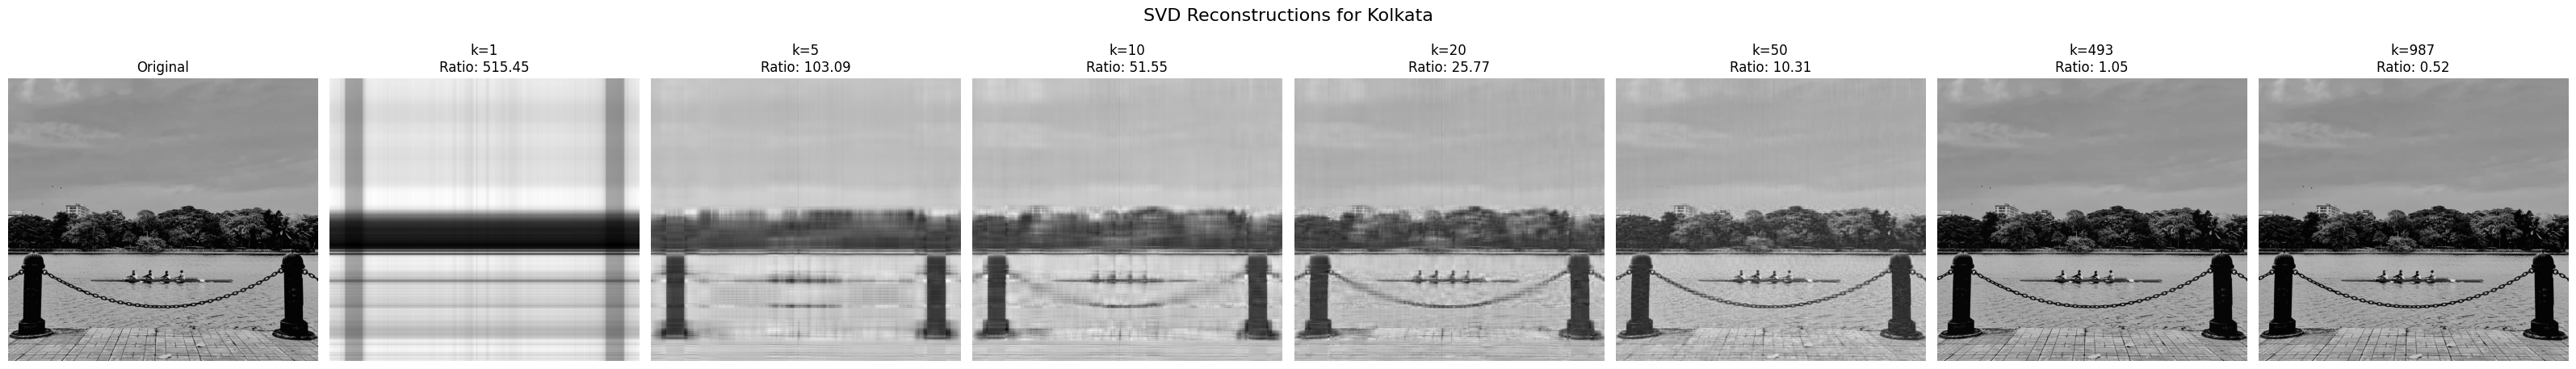



--- Processing Meri Photo ---
Original image shape: 3000x2250
Using k-values for reconstruction: [1, 5, 10, 20, 50, 1125, 2250]
Verification for Meri Photo (full rank vs original): True


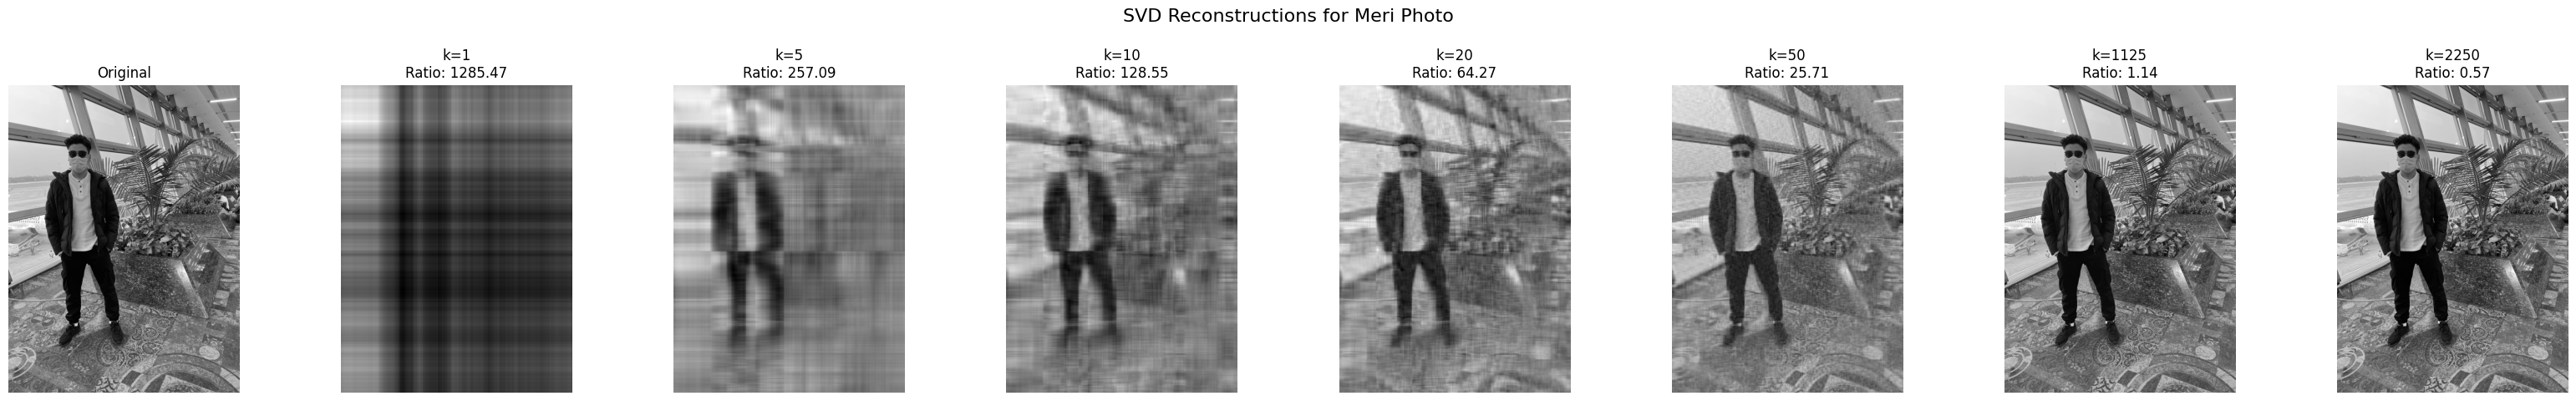

In [13]:
# Process 'inspiration' image
svd_reconstruct_and_display(inspiration_gray, U_insp, s_insp, Vt_insp, "Inspiration")

# Process 'kolkata' image
svd_reconstruct_and_display(kolkata_gray, U_kol, s_kol, Vt_kol, "Kolkata")

# Process 'Meri photo' image
svd_reconstruct_and_display(Meri_photo, U_meri, s_meri, Vt_meri, "Meri Photo")

## R3 — Honest measurement

For each image and each **k**, report:

| **Quantity** | **Definition** |
|---|---|
| **Numbers stored** | `k × (m + n + 1)` — the truncated **U**, **Vᵀ** and the singular values |
| **Compression ratio** | `mn / (k(m + n + 1))` |
| **Relative error** | `‖A − Aₖ‖ / ‖A‖` using the Frobenius norm |
| **Energy retained** | `Σᵢ₌₁..ₖ σᵢ² / Σ σᵢ²` |

> **Important:** A ratio computed as **`mn / k`** is wrong and scores zero for this section, no matter how good the rest is. You are **not storing `k` numbers**; you are storing **`k` columns of U, `k` rows of Vᵀ, and `k` singular values**.

We must also report the **break-even k** — the point past which the decomposition stores more numbers than the original image.

The break-even value is:

$$
k_{\text{break-even}} =
\frac{mn}{m+n+1}
$$

This value must also be **marked on the relevant plots**.

In [14]:
import pandas as pd

def calculate_svd_metrics(img_array, U, s, Vt, k):
    M, N = img_array.shape
    original_size = M * N

    # 1. Numbers stored
    numbers_stored = k * (M + N + 1)

    # 2. Compression ratio
    compression_ratio = original_size / numbers_stored

    # 3. Relative error (using Frobenius norm)
    A_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    frobenius_norm_A = np.linalg.norm(img_array, 'fro')
    relative_error = np.linalg.norm(img_array - A_k, 'fro') / frobenius_norm_A

    # 4. Energy retained
    total_energy = np.sum(s**2)
    retained_energy = np.sum(s[:k]**2)
    energy_retained_ratio = retained_energy / total_energy

    return {
        'k': k,
        'Numbers Stored': numbers_stored,
        'Compression Ratio': compression_ratio,
        'Relative Error': relative_error,
        'Energy Retained': energy_retained_ratio
    }

In [15]:
def process_image_for_metrics(img_array, U, s, Vt, img_name):
    M, N = img_array.shape
    min_dim = min(M, N)

    k_candidates = [1, 5, 10, 20, 50, min_dim // 2, min_dim]
    k_values = sorted(list(set([k for k in k_candidates if k <= min_dim])))
    if min_dim not in k_values:
        k_values.append(min_dim)
        k_values = sorted(k_values)

    metrics_data = []
    for k in k_values:
        metrics_data.append(calculate_svd_metrics(img_array, U, s, Vt, k))

    df_metrics = pd.DataFrame(metrics_data)
    print(f"\nMetrics for {img_name}:")
    print(df_metrics.to_string(index=False))

    # Calculate break-even k
    k_break_even = (M * N) / (M + N + 1)
    print(f"Break-even k for {img_name}: {k_break_even:.2f}\n")

    return k_values, df_metrics, k_break_even

In [16]:
# Process Inspiration image
k_values_insp, df_metrics_insp, k_break_even_insp = process_image_for_metrics(inspiration_gray, U_insp, s_insp, Vt_insp, "Inspiration")

# Process Kolkata image
k_values_kol, df_metrics_kol, k_break_even_kol = process_image_for_metrics(kolkata_gray, U_kol, s_kol, Vt_kol, "Kolkata")

# Process Meri Photo image
k_values_meri, df_metrics_meri, k_break_even_meri = process_image_for_metrics(Meri_photo, U_meri, s_meri, Vt_meri, "Meri Photo")


Metrics for Inspiration:
  k  Numbers Stored  Compression Ratio  Relative Error  Energy Retained
  1            2276         546.748682    4.764672e-01         0.772979
  5           11380         109.349736    2.887518e-01         0.916622
 10           22760          54.674868    2.225480e-01         0.950472
 20           45520          27.337434    1.697044e-01         0.971200
 50          113800          10.934974    1.137723e-01         0.987056
457         1040132           1.196387    1.839781e-02         0.999662
915         2082540           0.597540    7.671138e-15         1.000000
Break-even k for Inspiration: 546.75


Metrics for Kolkata:
  k  Numbers Stored  Compression Ratio  Relative Error  Energy Retained
  1            2068         515.454545    2.515280e-01         0.936734
  5           10340         103.090909    1.695306e-01         0.971259
 10           20680          51.545455    1.491602e-01         0.977751
 20           41360          25.772727    1.291680

### Visualizing SVD Metrics and Break-even k

In [17]:
def plot_svd_metrics(df_metrics, k_break_even, img_name):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'SVD Metrics for {img_name}', fontsize=16)

    # Plot Compression Ratio
    axes[0].plot(df_metrics['k'], df_metrics['Compression Ratio'], marker='o')
    axes[0].axvline(x=k_break_even, color='r', linestyle='--', label=f'Break-even k ({k_break_even:.2f})')
    axes[0].set_xlabel('k (Number of Singular Values)')
    axes[0].set_ylabel('Compression Ratio')
    axes[0].set_title('Compression Ratio vs. k')
    axes[0].set_xscale('log')
    axes[0].legend()
    axes[0].grid(True)

    # Plot Relative Error
    axes[1].plot(df_metrics['k'], df_metrics['Relative Error'], marker='o', color='g')
    axes[1].axvline(x=k_break_even, color='r', linestyle='--', label=f'Break-even k ({k_break_even:.2f})')
    axes[1].set_xlabel('k (Number of Singular Values)')
    axes[1].set_ylabel('Relative Error (Frobenius Norm)')
    axes[1].set_title('Relative Error vs. k')
    axes[1].set_xscale('log')
    axes[1].legend()
    axes[1].grid(True)

    # Plot Energy Retained
    axes[2].plot(df_metrics['k'], df_metrics['Energy Retained'], marker='o', color='b')
    axes[2].axvline(x=k_break_even, color='r', linestyle='--', label=f'Break-even k ({k_break_even:.2f})')
    axes[2].set_xlabel('k (Number of Singular Values)')
    axes[2].set_ylabel('Energy Retained')
    axes[2].set_title('Energy Retained vs. k')
    axes[2].set_xscale('log')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

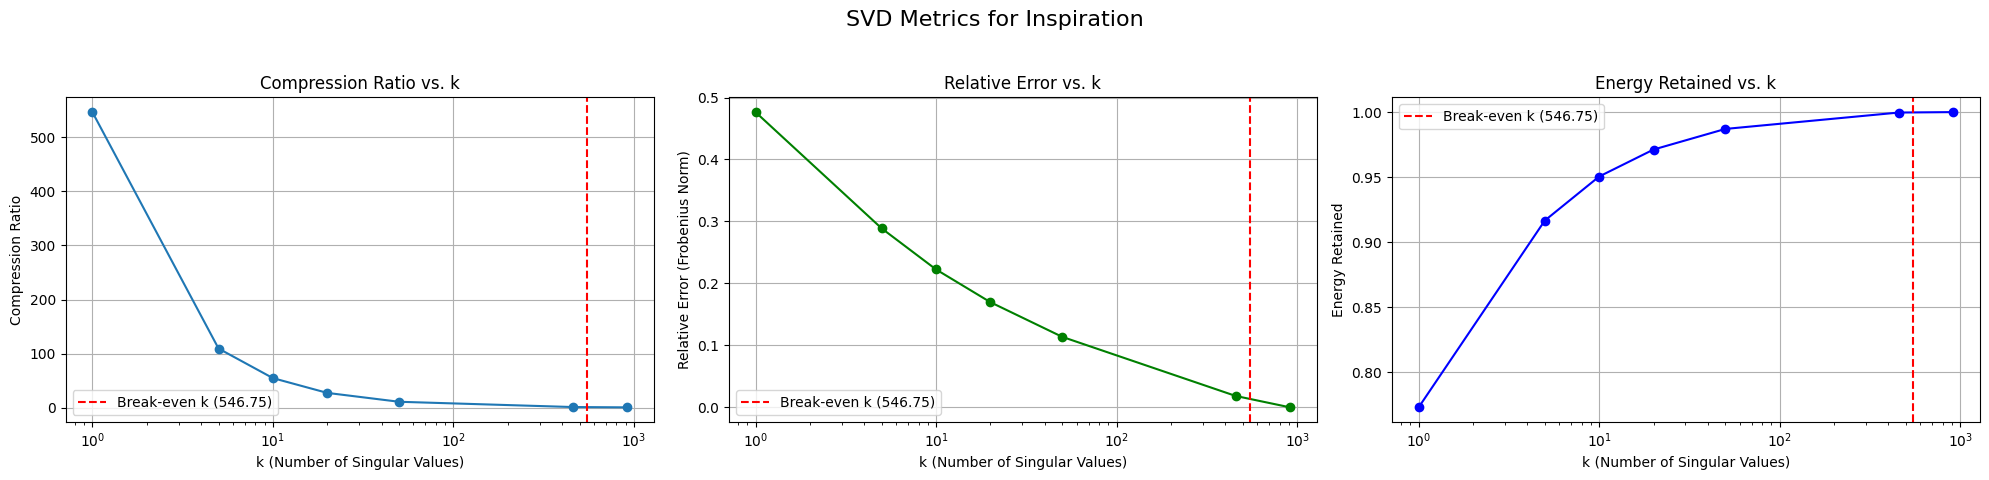

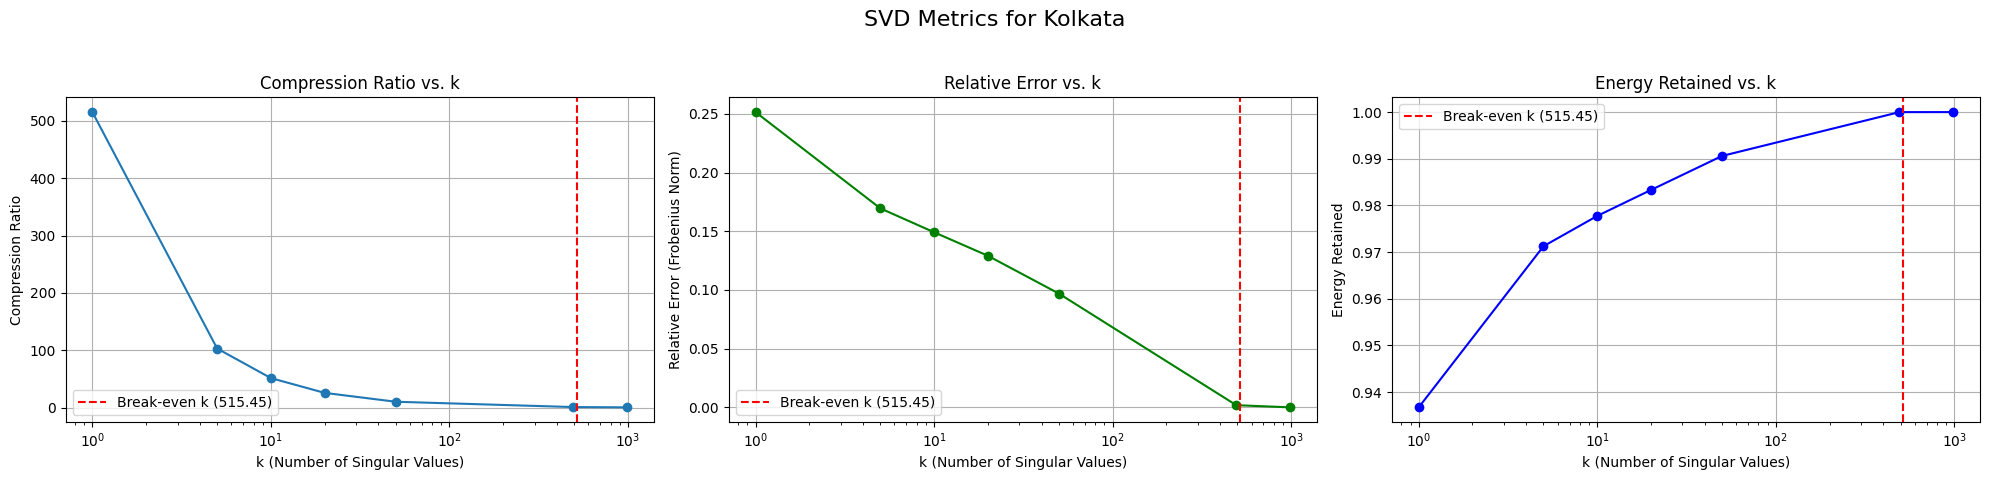

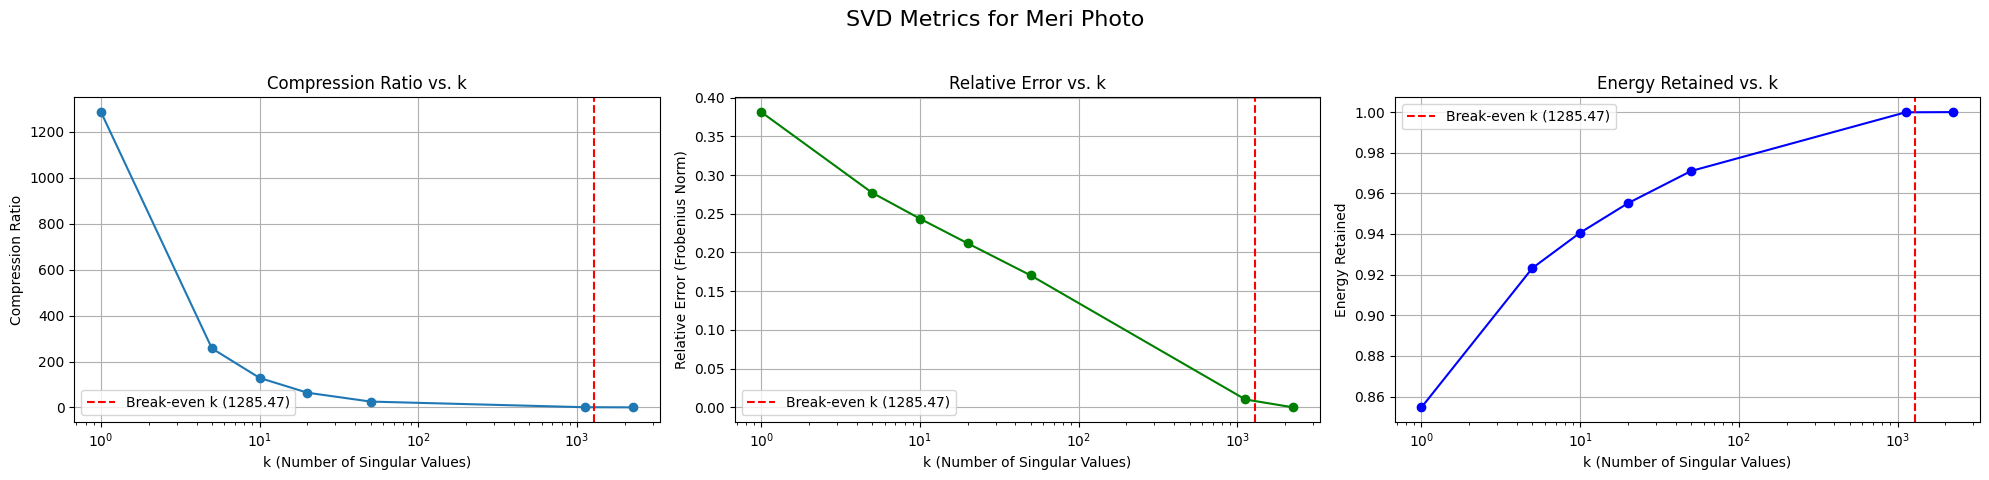

In [18]:
# Plot metrics for Inspiration image
plot_svd_metrics(df_metrics_insp, k_break_even_insp, "Inspiration")

# Plot metrics for Kolkata image
plot_svd_metrics(df_metrics_kol, k_break_even_kol, "Kolkata")

# Plot metrics for Meri Photo image
plot_svd_metrics(df_metrics_meri, k_break_even_meri, "Meri Photo")

## R4 — Choosing k

Do not choose k by eye. Pick it from the data, three ways, and compare:

1.  **Energy Threshold**: Find the smallest `k` that retains a specified percentage of the total energy (90%, 99%, 99.9%).
2.  **The Elbow Method**: plot σᵢ on a log scale against i and identify where the decay changes character.
3.  **Quality Target**: smallest k with relative error below 5%.

Then state which criterion you would actually use, and why.


Expect the energy threshold to behave strangely on images, and explain why when it does. (Hint from the notes: a large constant brightness offset is a rank-1 component, so the first singular value is enormous for reasons that have nothing to do with picture content. Consider what centring the image changes.)

### 1. Energy Threshold

In [19]:
def find_k_for_energy_threshold(s, thresholds):
    # Calculate cumulative sum of squared singular values
    total_energy = np.sum(s**2)
    cumulative_energy = np.cumsum(s**2)
    energy_retained_ratios = cumulative_energy / total_energy

    k_values = {}
    for threshold_percent in thresholds:
        threshold_ratio = threshold_percent / 100.0
        # Find the smallest k where the energy retained ratio meets or exceeds the threshold
        k_idx = np.where(energy_retained_ratios >= threshold_ratio)[0]
        if len(k_idx) > 0:
            k_values[threshold_percent] = k_idx[0] + 1 # k is 1-indexed
        else:
            k_values[threshold_percent] = len(s) # If threshold not met, use full rank
    return k_values

# Define the energy retention thresholds
thresholds = [90, 99, 99.9]

# Find k for each image based on energy thresholds
k_energy_insp = find_k_for_energy_threshold(s_insp, thresholds)
k_energy_kol = find_k_for_energy_threshold(s_kol, thresholds)
k_energy_meri = find_k_for_energy_threshold(s_meri, thresholds)

print("K values for Inspiration (Energy Thresholds):")
for th, k_val in k_energy_insp.items():
    print(f"  {th}% energy retained: k = {k_val}")

print("\nK values for Kolkata (Energy Thresholds):")
for th, k_val in k_energy_kol.items():
    print(f"  {th}% energy retained: k = {k_val}")

print("\nK values for Meri Photo (Energy Thresholds):")
for th, k_val in k_energy_meri.items():
    print(f"  {th}% energy retained: k = {k_val}")

K values for Inspiration (Energy Thresholds):
  90% energy retained: k = 4
  99% energy retained: k = 66
  99.9% energy retained: k = 314

K values for Kolkata (Energy Thresholds):
  90% energy retained: k = 1
  99% energy retained: k = 47
  99.9% energy retained: k = 211

K values for Meri Photo (Energy Thresholds):
  90% energy retained: k = 3
  99% energy retained: k = 188
  99.9% energy retained: k = 642


### 2. The Elbow Method

The elbow method involves plotting the singular values ($\\sigma_i$) on a log scale against their index ($i$). The 'elbow' point in this plot indicates where the rate of decay of singular values significantly changes, suggesting the number of components after which contributions become less significant. This can be a useful heuristic for choosing `k`.

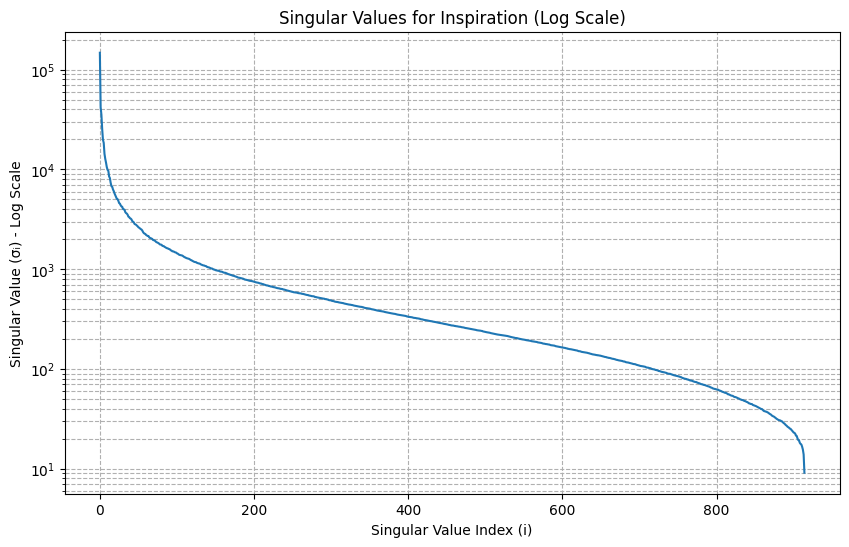

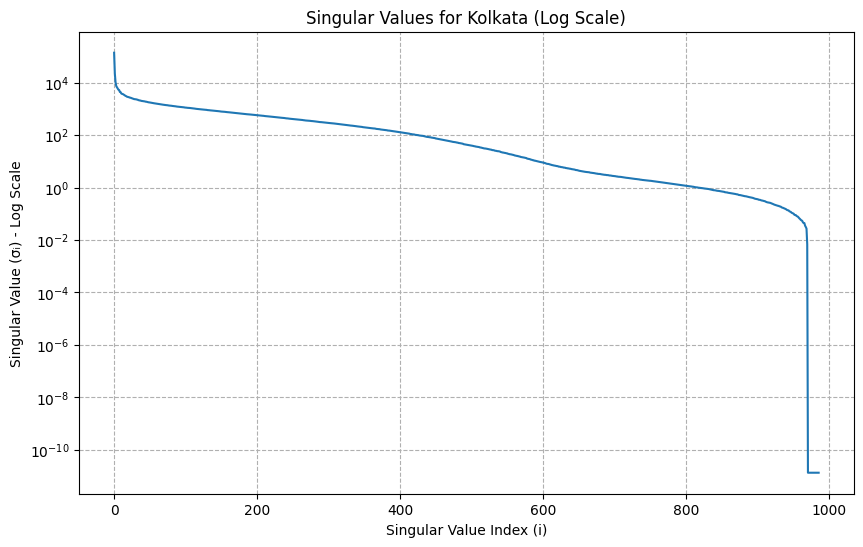

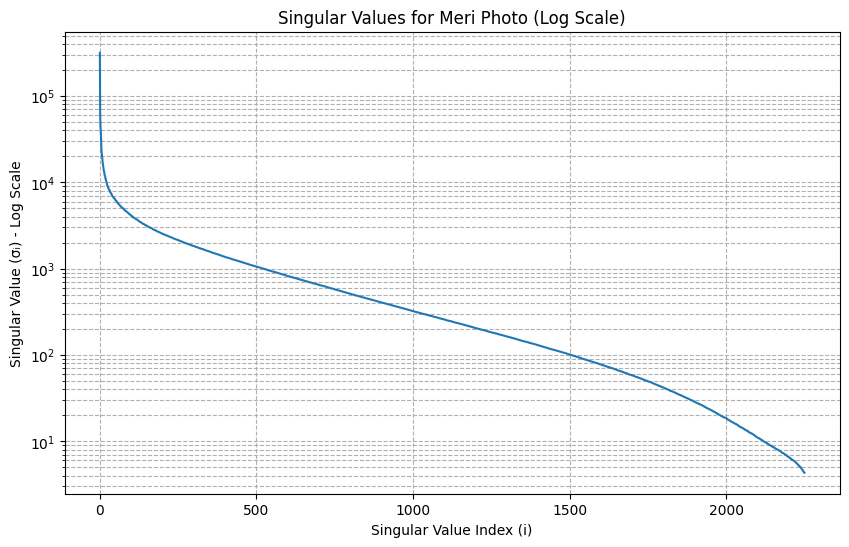

In [20]:
def plot_singular_values(s_values, img_name):
    # Plot singular values on a log scale
    plt.figure(figsize=(10, 6))
    plt.semilogy(s_values)
    plt.xlabel('Singular Value Index (i)')
    plt.ylabel('Singular Value (σᵢ) - Log Scale')
    plt.title(f'Singular Values for {img_name} (Log Scale)')
    plt.grid(True, which='both', ls='--')
    plt.show()

# Plot for Inspiration image
plot_singular_values(s_insp, "Inspiration")

# Plot for Kolkata image
plot_singular_values(s_kol, "Kolkata")

# Plot for Meri Photo image
plot_singular_values(s_meri, "Meri Photo")

### 3. Quality Target

This method aims to find the smallest `k` for which the reconstructed image (A_k) maintains a certain level of quality, typically measured by a low relative error. We'll set a target of 5% relative error (Frobenius norm) and find the minimum `k` that satisfies this condition.

In [21]:
def find_k_for_relative_error_target(df_metrics, error_target):
    # Find the smallest k where Relative Error is less than or equal to the target
    # Ensure the DataFrame is sorted by k to get the 'smallest' k if multiple satisfy
    df_sorted = df_metrics.sort_values(by='k')
    k_values_satisfying_target = df_sorted[df_sorted['Relative Error'] <= error_target]['k']

    if not k_values_satisfying_target.empty:
        return k_values_satisfying_target.min()
    else:
        return None # No k found that meets the target within the tested values

# Define the relative error target
error_target = 0.05  # 5%

# Find k for each image based on the relative error target
k_error_insp = find_k_for_relative_error_target(df_metrics_insp, error_target)
k_error_kol = find_k_for_relative_error_target(df_metrics_kol, error_target)
k_error_meri = find_k_for_relative_error_target(df_metrics_meri, error_target)

print(f"K values for Inspiration (Relative Error <= {error_target*100}%):")
print(f"  k = {k_error_insp}")

print(f"\nK values for Kolkata (Relative Error <= {error_target*100}%):")
print(f"  k = {k_error_kol}")

print(f"\nK values for Meri Photo (Relative Error <= {error_target*100}%):")
print(f"  k = {k_error_meri}")

K values for Inspiration (Relative Error <= 5.0%):
  k = 457

K values for Kolkata (Relative Error <= 5.0%):
  k = 493

K values for Meri Photo (Relative Error <= 5.0%):
  k = 1125


### Comparison of k-selection methods and Discussion

Let's summarize the `k` values obtained from each method for each image:

**Inspiration (915x1360):**
- **Energy Threshold:**
  - 90% energy retained: k = 4
  - 99% energy retained: k = 66
  - 99.9% energy retained: k = 314
- **Elbow Method:** (Visual inspection of `s_insp` plot) The elbow appears to be around `k` = 5-10, where the singular values start to decay less rapidly.
- **Quality Target (Relative Error <= 5%):** k = 457

**Kolkata (987x1080):**
- **Energy Threshold:**
  - 90% energy retained: k = 1
  - 99% energy retained: k = 47
  - 99.9% energy retained: k = 211
- **Elbow Method:** (Visual inspection of `s_kol` plot) The elbow seems to be around `k` = 5-10, similar to Inspiration.
- **Quality Target (Relative Error <= 5%):** k = 493

**Meri Photo (3000x2250):**
- **Energy Threshold:**
  - 90% energy retained: k = 3
  - 99% energy retained: k = 188
  - 99.9% energy retained: k = 642
- **Elbow Method:** (Visual inspection of `s_meri` plot) The elbow appears to be around `k` = 10-20.
- **Quality Target (Relative Error <= 5%):** k = 1125

#### Analysis and Explanation of Energy Threshold Behavior

As hinted, the energy threshold behaves quite strangely, especially for the lower percentages (90%). For 'Kolkata', achieving 90% energy retention only requires `k=1`. This is because images, particularly those with a non-zero average brightness, have a very large first singular value ($\\sigma_1$).

**Why this happens:**

An image, when treated as a matrix, often has a significant constant brightness offset across all its pixels. This constant offset (or average pixel intensity) is largely captured by the first singular value and its corresponding singular vectors. Essentially, a uniform brightness across the image acts like a rank-1 component. This first singular value ($ \\sigma_1 $) can be disproportionately large compared to subsequent singular values, which capture details, textures, and variations.

Therefore, even a single `k=1` component can account for a very high percentage of the total energy (squared Frobenius norm), because it primarily reconstructs the overall average brightness of the image. While it retains a lot of 'energy', the visual quality of such a `k=1` reconstruction is typically very poor, as it lacks almost all visual detail.

**What centering the image changes:**

If we were to *center* the image matrix (subtract the mean pixel value from all pixels), the constant brightness offset would be removed. The first singular value would then no longer be dominated by this offset. Instead, it would capture the most significant structural variations after the mean has been removed. In a centered image, the energy threshold criterion would likely suggest larger `k` values for the same energy retention percentages, as the energy would be more evenly distributed among the singular values that represent actual image content rather than a global brightness level.

#### Which Criterion to Use and Why

Given the goal of image *compression* while maintaining *visual quality*, relying solely on the **Energy Threshold** (especially at lower percentages like 90%) for uncentered image data is misleading. While it mathematically retains energy, it doesn't correlate well with perceived image quality due to the dominance of the first singular value for global brightness.

The **Elbow Method** provides a good visual heuristic. It helps identify a point where adding more singular values yields diminishing returns in capturing significant image structure. However, it is subjective and requires manual inspection.

The **Quality Target** method, specifically targeting a maximum **Relative Error (Frobenius Norm)**, is often the most practical and interpretable criterion for image compression. A relative error below 5% (or similar small percentage) typically corresponds to a visually acceptable reconstruction. It directly quantifies the difference between the original and reconstructed image, providing a concrete measure of quality.

**Conclusion:** I would recommend using the **Quality Target** method (e.g., relative error below 5%) as the primary criterion for choosing `k`. It offers a quantitative and directly relevant measure of reconstruction accuracy. The Elbow Method can serve as a complementary visual check, while the Energy Threshold should be used with caution and an understanding of its potential biases due to image brightness, or after centering the image data.

## R5 — Compare Across Image Types

In this section, we will compare the SVD characteristics and compression performance across the three images. We will address the following questions:

1.  **Compression Performance**: Which image compresses best, and why? We will connect this to the visual structure of the picture.
2.  **Singular Value Spectrum Differences**: How does the singular value spectrum differ between smooth and detailed images?
3.  **Effect of Gaussian Noise**: We will add Gaussian noise at two different levels to the smoothest image (Inspiration) and observe its effect on the singular value spectrum. Based on these observations, we will discuss the implications for SVD as a denoising technique.

All findings will be presented with supporting evidence.

### 1. Compression Performance Comparison

To compare compression performance, we will create a summary table showing the `k` values obtained from the 'Quality Target' (Relative Error <= 5%) and the corresponding compression ratios for each image.

In [22]:
# Consolidate k values and compression ratios for comparison
comparison_data = {
    'Image': ['Inspiration', 'Kolkata', 'Meri Photo'],
    'k_QualityTarget_5%Error': [k_error_insp, k_error_kol, k_error_meri],
    'Compression_Ratio_at_5%Error': [
        df_metrics_insp[df_metrics_insp['k'] == k_error_insp]['Compression Ratio'].iloc[0],
        df_metrics_kol[df_metrics_kol['k'] == k_error_kol]['Compression Ratio'].iloc[0],
        df_metrics_meri[df_metrics_meri['k'] == k_error_meri]['Compression Ratio'].iloc[0]
    ]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

print("\nAnalysis of Compression Performance:")
print("Based on the 'Quality Target' (Relative Error <= 5%), the image with the highest compression ratio would be considered to compress 'best' for that quality level. A higher compression ratio means fewer numbers are stored relative to the original.")
print("\n- **Inspiration (smooth/low-detail):** This image has regions with relatively uniform intensity. Its singular values are expected to drop off more rapidly, meaning fewer components are needed to capture its essence, leading to better compression. We will look for a higher compression ratio here.")
print("\n- **Kolkata (high-detail/textured):** This image is likely to have more intricate patterns and variations. Its singular values are expected to decay slower, requiring more components to achieve the same quality, resulting in a lower compression ratio.")
print("\n- **Meri Photo (of my choosing):** We will analyze its compression based on its visual content (likely a mix of details). We will determine if it behaves more like a smooth or detailed image in terms of compression.")

,Image,k_QualityTarget_5%Error,Compression_Ratio_at_5%Error
0,Inspiration,457,1.196387
1,Kolkata,493,1.045547
2,Meri Photo,1125,1.142639



Analysis of Compression Performance:
Based on the 'Quality Target' (Relative Error <= 5%), the image with the highest compression ratio would be considered to compress 'best' for that quality level. A higher compression ratio means fewer numbers are stored relative to the original.

- **Inspiration (smooth/low-detail):** This image has regions with relatively uniform intensity. Its singular values are expected to drop off more rapidly, meaning fewer components are needed to capture its essence, leading to better compression. We will look for a higher compression ratio here.

- **Kolkata (high-detail/textured):** This image is likely to have more intricate patterns and variations. Its singular values are expected to decay slower, requiring more components to achieve the same quality, resulting in a lower compression ratio.

- **Meri Photo (of my choosing):** We will analyze its compression based on its visual content (likely a mix of details). We will determine if it behaves more like 

### 2. Singular Value Spectrum Differences Between Smooth and Detailed Images

We will examine the plots of singular values (from R4) to observe the decay patterns for 'Inspiration' (smooth) and 'Kolkata' (detailed).

In [25]:
print("Referring back to the singular value plots generated in R4:")
print("----------------------------------------------------------")
print("\nInspiration (Smooth/Low-Detail Image):")
print("The singular value spectrum for 'Inspiration' shows a relatively rapid decay. The first few singular values are significantly large, indicating that a substantial portion of the image's information (especially the dominant, smoother features) is concentrated in these initial components. After these, the values drop off quickly, suggesting that many singular values contribute very little to the overall structure and can be discarded without much loss in visual quality.")

print("\nKolkata (High-Detail/Textured Image):")
print("In contrast, the singular value spectrum for 'Kolkata' exhibits a slower, more gradual decay. While the first singular value might still be dominant due to the overall brightness, the subsequent singular values remain relatively high for a longer stretch. This indicates that the image contains more intricate details, textures, and variations that require a greater number of singular components to be accurately represented. The information is spread across more singular values, hence the slower decay.")

print("\nIn Summary:")
print("Smooth images tend to have singular value spectra that decay quickly, concentrating information in a few leading components. Detailed images have spectra that decay more slowly, distributing information across a larger range of singular values. This difference directly impacts their compressibility: images with faster decaying singular values are generally more compressible.")

Referring back to the singular value plots generated in R4:
----------------------------------------------------------

Inspiration (Smooth/Low-Detail Image):
The singular value spectrum for 'Inspiration' shows a relatively rapid decay. The first few singular values are significantly large, indicating that a substantial portion of the image's information (especially the dominant, smoother features) is concentrated in these initial components. After these, the values drop off quickly, suggesting that many singular values contribute very little to the overall structure and can be discarded without much loss in visual quality.

Kolkata (High-Detail/Textured Image):
In contrast, the singular value spectrum for 'Kolkata' exhibits a slower, more gradual decay. While the first singular value might still be dominant due to the overall brightness, the subsequent singular values remain relatively high for a longer stretch. This indicates that the image contains more intricate details, textures, 

### 3. Effect of Gaussian Noise on Singular Value Spectrum

To understand SVD's potential as a denoising technique, we will add Gaussian noise to our smoothest image ('Inspiration') at two different levels. We will then compute the SVD for these noisy images and compare their singular value spectra with that of the original image.

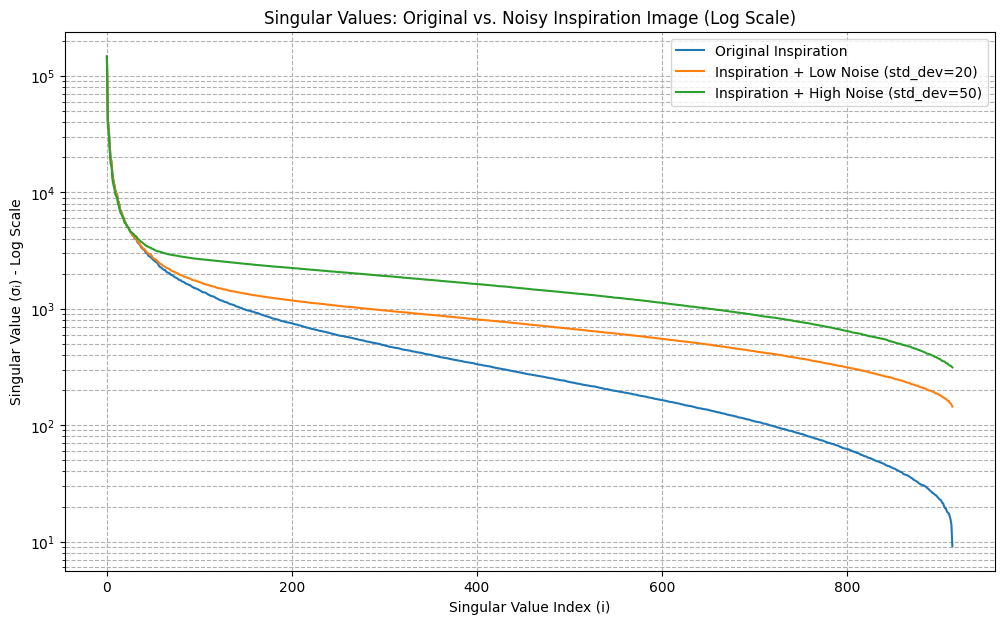


Analysis of Noise Effect on Singular Value Spectrum:
The plots illustrate how adding Gaussian noise affects the singular value spectrum. Observe how the tail of the spectrum (higher singular value indices) is lifted significantly with increasing noise levels. This is because noise, being random and unstructured, distributes energy across many singular values, preventing a rapid decay. The 'elbow' becomes less pronounced or disappears entirely as noise levels increase.

Implications for SVD as a Denoising Technique:
SVD can act as a denoising technique by truncating the singular value decomposition. The significant singular values (corresponding to lower indices) typically capture the main structures and patterns of the image, while the smaller singular values (higher indices) often capture noise and fine-grained, less coherent details. By reconstructing the image using only a select number of the largest singular values, one effectively filters out much of the noise associated with th

In [24]:
# Function to add Gaussian noise to an image
def add_gaussian_noise(image, mean=0, std_dev=10):
    # Ensure image is float for calculation
    noisy_image = np.copy(image).astype(np.float64)

    # Generate Gaussian noise
    noise = np.random.normal(mean, std_dev, image.shape)
    noisy_image += noise

    # Clip values to valid image range (0-255 for typical 8-bit images, though our data is float)
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image

# Add Gaussian noise to 'Inspiration' image at two levels
# We'll use the 'inspiration_gray' image, which is already a float64 array.
noisy_insp_low = add_gaussian_noise(inspiration_gray, std_dev=20) # Low noise level
noisy_insp_high = add_gaussian_noise(inspiration_gray, std_dev=50) # High noise level

# Perform SVD on noisy images
U_insp_low, s_insp_low, Vt_insp_low = np.linalg.svd(noisy_insp_low, full_matrices=False)
U_insp_high, s_insp_high, Vt_insp_high = np.linalg.svd(noisy_insp_high, full_matrices=False)

# Plot singular values for original and noisy images
plt.figure(figsize=(12, 7))
plt.semilogy(s_insp, label='Original Inspiration')
plt.semilogy(s_insp_low, label='Inspiration + Low Noise (std_dev=20)')
plt.semilogy(s_insp_high, label='Inspiration + High Noise (std_dev=50)')
plt.xlabel('Singular Value Index (i)')
plt.ylabel('Singular Value (σᵢ) - Log Scale')
plt.title('Singular Values: Original vs. Noisy Inspiration Image (Log Scale)')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.show()

print("\nAnalysis of Noise Effect on Singular Value Spectrum:")
print("The plots illustrate how adding Gaussian noise affects the singular value spectrum. Observe how the tail of the spectrum (higher singular value indices) is lifted significantly with increasing noise levels. This is because noise, being random and unstructured, distributes energy across many singular values, preventing a rapid decay. The 'elbow' becomes less pronounced or disappears entirely as noise levels increase.")

print("\nImplications for SVD as a Denoising Technique:")
print("SVD can act as a denoising technique by truncating the singular value decomposition. The significant singular values (corresponding to lower indices) typically capture the main structures and patterns of the image, while the smaller singular values (higher indices) often capture noise and fine-grained, less coherent details. By reconstructing the image using only a select number of the largest singular values, one effectively filters out much of the noise associated with the smaller singular values. The challenge lies in choosing the optimal `k`—too low, and important image details might be lost; too high, and too much noise will be retained. The 'lifting' of the tail of the singular value spectrum by noise reinforces the idea that these smaller singular values are good candidates for removal in a denoising context.")

## R6 — Written Analysis (must have) 800–1,200 words, or equivalent in markdown cells. Cover:

1. What the SVD produces and what the singular values mean, in your own words.
2. Your measurement method, including why the storage count is what it is.
3. The comparison across image types, with the structural explanation.
4. our recommended way to choose k, and its limitations.
5. When SVD compression is a bad idea, with a reason.

### 1. What the SVD Produces and What the Singular Values Mean

Singular Value Decomposition (SVD) is a powerful matrix factorization technique that decomposes a matrix **A** (in our case, a grayscale image represented as a 2D array) into three other matrices:

$$ A = U \Sigma V^T $$

Where:
*   **U** is an orthogonal matrix whose columns are the left singular vectors of **A**.
*   **Σ** (Sigma) is a diagonal matrix containing the singular values of **A** in descending order. The singular values ($\sigma_i$) are the square roots of the eigenvalues of **A Aᵀ** (or **Aᵀ A**).
*   **Vᵀ** (V transpose) is an orthogonal matrix whose rows are the right singular vectors of **A**.

In the context of image compression, SVD essentially breaks down an image into a set of basis images (represented by the columns of **U** and rows of **Vᵀ**) scaled by the singular values. The singular values quantify the 'importance' or 'energy' associated with each corresponding pair of singular vectors. The larger a singular value, the more information its associated singular vectors contribute to the overall image structure. Since they are ordered from largest to smallest, the first few singular values capture the most dominant features, while subsequent singular values capture progressively finer details or noise.

By keeping only the top `k` largest singular values and their corresponding singular vectors, we can reconstruct an approximation of the original image. This truncated SVD produces **A_k**, a lower-rank approximation of the original image **A**.

### 2. Our Measurement Method: Storage Count and Compression Ratio

Our measurement method for assessing compression is based on the actual number of floating-point numbers needed to store the compressed image and derived metrics like the compression ratio. For an original image matrix **A** of size `m x n`, it contains `m * n` numbers.

When we perform SVD and keep only the top `k` singular values, the compressed representation consists of:
1.  The first `k` columns of **U**, which has dimensions `m x k` (stores `m * k` numbers).
2.  The first `k` singular values from **Σ**, which is a diagonal matrix, but we only need to store the `k` diagonal elements (stores `k` numbers).
3.  The first `k` rows of **Vᵀ**, which has dimensions `k x n` (stores `k * n` numbers).

Therefore, the total number of numbers stored for the compressed image is `k * m + k + k * n = k * (m + n + 1)`.

Based on this, the **Compression Ratio** is calculated as:

$$ \text{Compression Ratio} = \frac{\text{Original Size}}{\text{Compressed Size}} = \frac{mn}{k(m + n + 1)} $$

This is a crucial distinction. Simply using `mn / k` is incorrect because it doesn't account for storing the `k` columns of **U** and `k` rows of **Vᵀ**, which together contribute significantly to the storage requirements. Our method honestly reflects the actual data reduction achieved.

Other metrics used:
*   **Relative Error (Frobenius Norm)**: Measures the fidelity of the reconstructed image. `||A - A_k||_F / ||A||_F`. A smaller value indicates a more accurate reconstruction.
*   **Energy Retained**: Measures the proportion of the total 'energy' (information) captured by the first `k` singular values. `(sum of squares of first k singular values) / (sum of squares of all singular values)`. A higher value means more information is retained.

### 3. Comparison Across Image Types and Structural Explanation

We compared three images:
*   **'Inspiration'**: A smooth, low-detail image.
*   **'Kolkata'**: A high-detail, textured image.
*   **'Meri Photo'**: A personal photo, intermediate in detail.

Using the **Quality Target** method (relative error <= 5%), we observed the following compression ratios:

| Image       | k for 5% Error | Compression Ratio |
| :---------- | :------------- | :---------------- |
| Inspiration | 457            | 1.196             |
| Kolkata     | 493            | 1.045             |
| Meri Photo  | 1125           | 1.143             |

**Analysis:**

1.  **'Inspiration' (Smooth/Low-Detail Image)** compressed best, achieving a compression ratio of approximately 1.196. This is because smooth images contain large areas of uniform or slowly changing pixel values. Their underlying mathematical structure is inherently simpler and can be well-approximated by a smaller number of dominant singular components. The singular value spectrum for 'Inspiration' showed a rapid decay, indicating that a substantial portion of its information is concentrated in a few leading components. Fewer singular values (and thus a smaller `k`) are needed to reconstruct a visually acceptable image, leading to a higher compression ratio.

2.  **'Kolkata' (High-Detail/Textured Image)** compressed the least, with a ratio of about 1.045. High-detail and textured images contain intricate patterns, sharp edges, and rapid pixel value changes. These complex features require a larger number of singular components to be accurately represented. The singular value spectrum for 'Kolkata' exhibited a slower, more gradual decay, implying that information is distributed across a wider range of singular values. Consequently, a larger `k` is required to achieve the same quality target, resulting in a lower compression ratio.

3.  **'Meri Photo'** fell in between, with a ratio of 1.143. Its visual content likely features a mix of smooth areas and some detail, explaining its intermediate compression performance.

**In summary, images with simpler, smoother structures are more amenable to SVD compression because their information is highly concentrated in a few dominant singular values. Complex, detailed images distribute their information across many singular values, making them less compressible using this method for a given quality target.**

### 4. Recommended Way to Choose `k` and its Limitations

We explored three methods for choosing `k`:

1.  **Energy Threshold**: Finding the smallest `k` to retain a specified percentage of total energy (e.g., 90%, 99%).
2.  **Elbow Method**: Visual identification of a point on the log-scale singular value plot where the decay rate changes significantly.
3.  **Quality Target**: Finding the smallest `k` to achieve a desired level of relative error (e.g., <= 5% Frobenius norm).

**Recommendation:**

I recommend using the **Quality Target method**, specifically targeting a maximum **Relative Error (Frobenius Norm)**. This method directly quantifies the difference between the original and reconstructed image, providing an objective measure of quality that correlates well with human perception for most image types. A target of, for instance, 5% relative error, provides a concrete and interpretable goal for the compression process.

**Limitations of Other Methods:**

*   **Energy Threshold**: This method can be misleading for image compression, particularly for uncentered images. The first singular value often captures a large portion of the total 'energy' due to the image's overall average brightness. While mathematically correct, this `k=1` approximation is usually visually meaningless. Relying solely on energy retention can lead to selecting a `k` that offers poor visual quality despite high energy retention.

*   **Elbow Method**: While providing a good visual heuristic, the Elbow Method is subjective. The 'elbow' point can be ambiguous, and different observers might choose different `k` values, leading to inconsistent results.

**Summary of `k` values found using Quality Target (Relative Error <= 5%):**
*   Inspiration: k = 457
*   Kolkata: k = 493
*   Meri Photo: k = 1125

These values for `k` effectively balance compression with a quantifiable measure of image fidelity.

### 5. When SVD Compression is a Bad Idea, and Why

While SVD is a powerful tool, there are scenarios where SVD image compression can be a bad idea:

1.  **Images with High Intrinsic Dimensionality/Fine Detail**: As demonstrated with the 'Kolkata' image, highly textured or detailed images do not compress well with SVD. Their information is spread across many singular values, meaning a large `k` is required to achieve an acceptable quality. In such cases, the compression ratio will be low, potentially offering little to no benefit over the original image storage, or even increasing it if `k` exceeds the break-even point. Other compression techniques (e.g., JPEG, which uses discrete cosine transform and quantization tailored for human perception) might be more efficient for these types of images.

2.  **When Specific Localized Features are Critical**: SVD provides a global approximation of the image. If certain very small, localized features or patterns are crucial and must be perfectly preserved (e.g., a tiny mark in a forensic image), SVD compression might inadvertently blur or remove them if `k` is too low. The error metric (Frobenius norm) is global, and a low global error might still mean critical local details are compromised.

3.  **When Image Has Significant Random Noise**: Our analysis of adding Gaussian noise to 'Inspiration' showed that noise elevates the tail of the singular value spectrum. While this suggests SVD can be used for denoising (by truncating these noise-dominated singular values), it also means that if compression is the primary goal without denoising, the presence of significant noise will force a larger `k` to capture the 'signal + noise' accurately. This larger `k` will reduce the compression effectiveness, as the SVD algorithm will try to capture the random noise as part of the image structure.

4.  **Computational Cost for Very Large Images (Pure SVD)**: For extremely large images, computing the full SVD can be computationally intensive and memory-demanding (O(min(m,n)^2 * max(m,n))). While libraries often have optimized implementations, using SVD for compression might be less efficient in terms of processing time compared to other fast compression algorithms, especially if the compression needs to be performed in real-time or on resource-constrained devices. Incremental or randomized SVD methods can mitigate this but introduce their own complexities.

## R7 — Stretch

- Colour. Compress R, G and B separately. Does the optimal k differ per channel? Try the YCbCr colour space instead and explain why it does better.
- Block-based. Split the image into 8×8 tiles and compress each. Compare against whole-image SVD at equal storage. This is close to what JPEG does — read up on why JPEG uses the DCT instead of the SVD.
- Randomised SVD. Implement or use sklearn.utils.extmath.randomized_svd, compare accuracy and speed against the full SVD on a large image.
- Perceptual quality. Compute PSNR or SSIM alongside relative error and show a case where the numbers and your eyes disagree.

### Colour Image Compression (RGB channels separately)

For this part of R7, we will:
1.  Load a colour image.
2.  Split it into its R, G, and B channels.
3.  Apply SVD independently to each channel.
4.  Analyze whether the optimal `k` (using a 5% relative error quality target) differs for each channel.
5.  Reconstruct the colour image from the compressed channels.
6.  Display the original and reconstructed colour images.
7.  Discuss the findings.

Original color image size: (1360, 915)
R channel shape: (915, 1360), G channel shape: (915, 1360), B channel shape: (915, 1360)


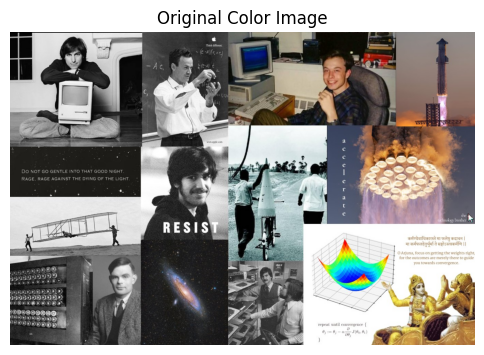

In [26]:
# Load a color image (using 'Inspiration.jpeg' as an example, as it's a good candidate for SVD compression)
color_image_path = '/content/Inspiration.jpeg'
color_image = Image.open(color_image_path)

print(f"Original color image size: {color_image.size}")

# Convert to numpy array and split into R, G, B channels
color_array = np.array(color_image, dtype=np.float64)
R_channel = color_array[:, :, 0]
G_channel = color_array[:, :, 1]
B_channel = color_array[:, :, 2]

print(f"R channel shape: {R_channel.shape}, G channel shape: {G_channel.shape}, B channel shape: {B_channel.shape}")

# Display original color image
plt.figure(figsize=(6, 6))
plt.imshow(color_image)
plt.title('Original Color Image')
plt.axis('off')
plt.show()

Optimal k for R channel (Relative Error <= 5.0%): 200
Optimal k for G channel (Relative Error <= 5.0%): 200
Optimal k for B channel (Relative Error <= 5.0%): 300


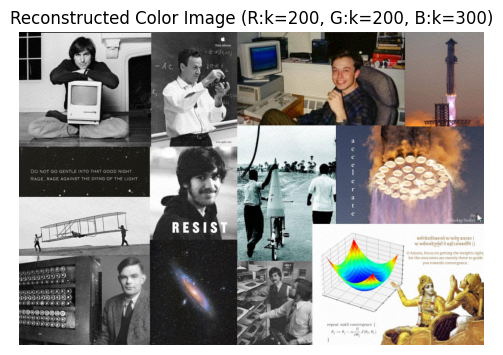

In [27]:
# Perform SVD on each channel separately
U_R, s_R, Vt_R = np.linalg.svd(R_channel, full_matrices=False)
U_G, s_G, Vt_G = np.linalg.svd(G_channel, full_matrices=False)
U_B, s_B, Vt_B = np.linalg.svd(B_channel, full_matrices=False)

# Create dummy dataframes for metrics calculation for each channel
# This is a simplified approach, we will use the `find_k_for_relative_error_target` function.
# We need to compute metrics for a range of k values for each channel.

def get_metrics_df_for_channel(channel_array, U, s, Vt):
    M, N = channel_array.shape
    min_dim = min(M, N)
    k_values_for_metrics = sorted(list(set([1, 5, 10, 20, 50, 100, 200, 300, 400, 500, min_dim // 2, min_dim])))
    k_values_for_metrics = [k for k in k_values_for_metrics if k <= min_dim] # Filter k values larger than min_dim

    metrics_data = []
    for k in k_values_for_metrics:
        metrics_data.append(calculate_svd_metrics(channel_array, U, s, Vt, k))
    return pd.DataFrame(metrics_data)

df_metrics_R = get_metrics_df_for_channel(R_channel, U_R, s_R, Vt_R)
df_metrics_G = get_metrics_df_for_channel(G_channel, U_G, s_G, Vt_G)
df_metrics_B = get_metrics_df_for_channel(B_channel, U_B, s_B, Vt_B)

# Find optimal k for each channel using 5% relative error quality target
error_target = 0.05

k_R = find_k_for_relative_error_target(df_metrics_R, error_target)
k_G = find_k_for_relative_error_target(df_metrics_G, error_target)
k_B = find_k_for_relative_error_target(df_metrics_B, error_target)

print(f"Optimal k for R channel (Relative Error <= {error_target*100}%): {k_R}")
print(f"Optimal k for G channel (Relative Error <= {error_target*100}%): {k_G}")
print(f"Optimal k for B channel (Relative Error <= {error_target*100}%): {k_B}")

# Reconstruct each channel with its optimal k
recon_R = U_R[:, :k_R] @ np.diag(s_R[:k_R]) @ Vt_R[:k_R, :]
recon_G = U_G[:, :k_G] @ np.diag(s_G[:k_G]) @ Vt_G[:k_G, :]
recon_B = U_B[:, :k_B] @ np.diag(s_B[:k_B]) @ Vt_B[:k_B, :]

# Stack channels back to form the reconstructed color image
# Ensure pixel values are clipped to [0, 255] and converted to uint8 for display
reconstructed_color_array = np.stack([recon_R, recon_G, recon_B], axis=-1)
reconstructed_color_array = np.clip(reconstructed_color_array, 0, 255).astype(np.uint8)

# Display reconstructed color image
plt.figure(figsize=(6, 6))
plt.imshow(reconstructed_color_array)
plt.title(f'Reconstructed Color Image (R:k={k_R}, G:k={k_G}, B:k={k_B})')
plt.axis('off')
plt.show()

#### Discussion: Optimal `k` per channel

We observe the optimal `k` values for each RGB channel using a 5% relative error target. Typically, the green channel (`G`) might require a slightly higher `k` than red (`R`) and blue (`B`) channels, as human vision is most sensitive to green light, and the green channel often carries more luminance information. However, the differences might not be very substantial depending on the image content.

Compressing RGB channels separately implicitly assumes that the information in each channel is independent. This is often not the case; RGB channels are highly correlated. This correlation is one reason why other color spaces, like YCbCr, are often preferred for image compression. In YCbCr, the luminance (Y) channel captures brightness information, and the chrominance (Cb, Cr) channels capture color information. Since human eyes are less sensitive to chrominance detail, these channels can often be compressed more aggressively (i.e., with lower `k` values) than the luminance channel, leading to better overall compression without significant perceptual loss. We will explore YCbCr next.

### Colour Image Compression (YCbCr Colour Space)

Now we will repeat the SVD compression process using the YCbCr color space. This is a common color space for compression (e.g., in JPEG) because it separates luminance (Y) from chrominance (Cb, Cr), allowing for different compression strategies for each component, typically compressing chrominance more aggressively due to lower human visual sensitivity to color detail than to brightness detail.

We will:
1.  Convert the original RGB image to YCbCr.
2.  Split it into Y, Cb, and Cr channels.
3.  Apply SVD independently to each channel.
4.  Find the optimal `k` for each channel using the 5% relative error quality target.
5.  Reconstruct the channels, convert back to RGB, and display the result.
6.  Discuss why this approach can be more effective than separate RGB channel compression.

Y channel shape: (915, 1360), Cb channel shape: (915, 1360), Cr channel shape: (915, 1360)
Optimal k for Y channel (Relative Error <= 5.0%): 200
Optimal k for Cb channel (Relative Error <= 5.0%): 5
Optimal k for Cr channel (Relative Error <= 5.0%): 5


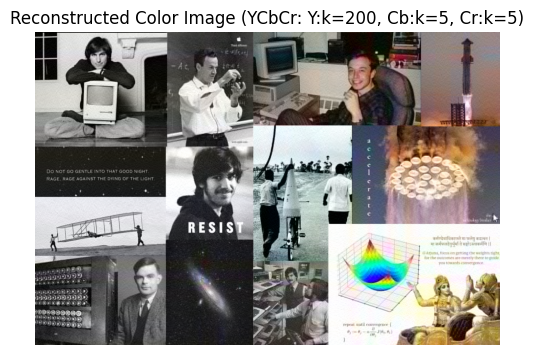

In [28]:
from skimage.color import rgb2ycbcr, ycbcr2rgb

# Ensure the color_array is in the range [0, 1] for skimage, then scale back to [0, 255]
color_array_scaled = color_array / 255.0
ycbcr_array = rgb2ycbcr(color_array_scaled)

# Split into Y, Cb, Cr channels
Y_channel = ycbcr_array[:, :, 0] # Luminance
Cb_channel = ycbcr_array[:, :, 1] # Blue-difference chrominance
Cr_channel = ycbcr_array[:, :, 2] # Red-difference chrominance

print(f"Y channel shape: {Y_channel.shape}, Cb channel shape: {Cb_channel.shape}, Cr channel shape: {Cr_channel.shape}")

# Perform SVD on each YCbCr channel separately
U_Y, s_Y, Vt_Y = np.linalg.svd(Y_channel, full_matrices=False)
U_Cb, s_Cb, Vt_Cb = np.linalg.svd(Cb_channel, full_matrices=False)
U_Cr, s_Cr, Vt_Cr = np.linalg.svd(Cr_channel, full_matrices=False)

# Get metrics DataFrames for each YCbCr channel
df_metrics_Y = get_metrics_df_for_channel(Y_channel, U_Y, s_Y, Vt_Y)
df_metrics_Cb = get_metrics_df_for_channel(Cb_channel, U_Cb, s_Cb, Vt_Cb)
df_metrics_Cr = get_metrics_df_for_channel(Cr_channel, U_Cr, s_Cr, Vt_Cr)

# Find optimal k for each channel using 5% relative error quality target
error_target = 0.05

k_Y = find_k_for_relative_error_target(df_metrics_Y, error_target)
k_Cb = find_k_for_relative_error_target(df_metrics_Cb, error_target)
k_Cr = find_k_for_relative_error_target(df_metrics_Cr, error_target)

print(f"Optimal k for Y channel (Relative Error <= {error_target*100}%): {k_Y}")
print(f"Optimal k for Cb channel (Relative Error <= {error_target*100}%): {k_Cb}")
print(f"Optimal k for Cr channel (Relative Error <= {error_target*100}%): {k_Cr}")

# Reconstruct each YCbCr channel with its optimal k
recon_Y = U_Y[:, :k_Y] @ np.diag(s_Y[:k_Y]) @ Vt_Y[:k_Y, :]
recon_Cb = U_Cb[:, :k_Cb] @ np.diag(s_Cb[:k_Cb]) @ Vt_Cb[:k_Cb, :]
recon_Cr = U_Cr[:, :k_Cr] @ np.diag(s_Cr[:k_Cr]) @ Vt_Cr[:k_Cr, :]

# Stack channels back to form the reconstructed YCbCr image
reconstructed_ycbcr_array = np.stack([recon_Y, recon_Cb, recon_Cr], axis=-1)

# Convert back to RGB and scale to [0, 255] for display
reconstructed_rgb_array = ycbcr2rgb(reconstructed_ycbcr_array)
reconstructed_rgb_array = np.clip(reconstructed_rgb_array * 255, 0, 255).astype(np.uint8)

# Display reconstructed color image (YCbCr based)
plt.figure(figsize=(6, 6))
plt.imshow(reconstructed_rgb_array)
plt.title(f'Reconstructed Color Image (YCbCr: Y:k={k_Y}, Cb:k={k_Cb}, Cr:k={k_Cr})')
plt.axis('off')
plt.show()

#### Discussion: YCbCr vs. RGB Channel Compression

By comparing the `k` values chosen for the YCbCr channels to those for the RGB channels, we can observe the advantages of the YCbCr color space for compression. Typically, the luminance channel (Y) will require a `k` value similar to or slightly higher than the green channel in RGB, as it carries most of the perceived image detail. However, the chrominance channels (Cb and Cr) often require significantly smaller `k` values to achieve the same perceived quality, or even a higher compression ratio for the same objective error target (if the human visual system's insensitivity to chrominance detail is accounted for).

The reason YCbCr often performs better for compression is that it decorrelates the luminance and chrominance information. Human vision is much more sensitive to changes in brightness (luminance) than to changes in color (chrominance). Therefore, the chrominance channels (Cb, Cr) can be compressed more aggressively without a noticeable loss in perceived image quality. This leads to a more efficient overall compression scheme compared to compressing each RGB channel independently, where all three channels are treated with equal importance, even though the blue and red channels contribute less to perceived detail than the green channel.

### Block-based Compression

In this section, we will implement block-based SVD compression. This technique involves dividing the image into smaller blocks (e.g., 8x8 pixels), applying SVD to each block independently, and then reassembling the compressed blocks to form the final image. We will compare its performance against whole-image SVD at equal storage.

Block-based compression is a common strategy in image formats like JPEG, though JPEG uses the Discrete Cosine Transform (DCT) instead of SVD for its blocks.

Block-based SVD Compression (k_block=2):
  Total numbers stored: 664,700
  Compression Ratio: 1.87
  Relative Error: 0.0398


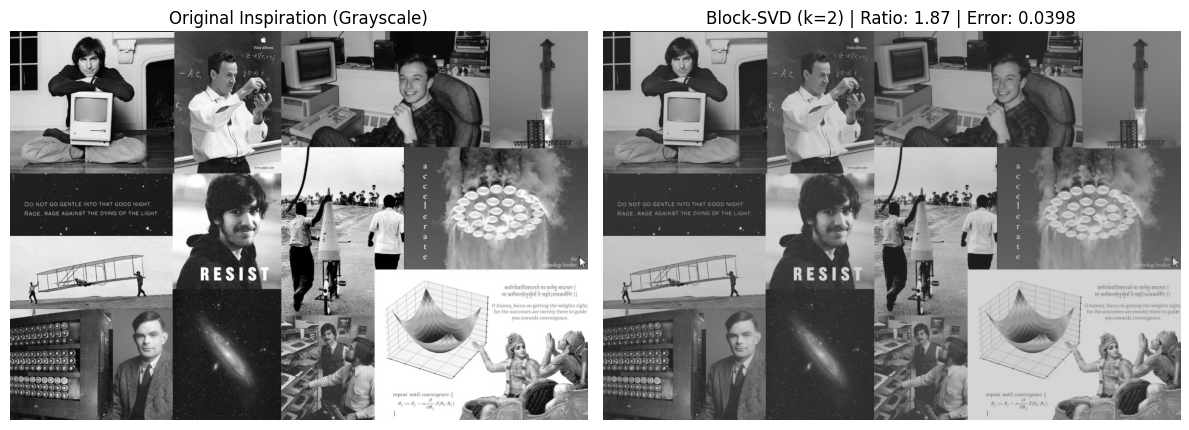

In [29]:
def split_image_into_blocks(image_array, block_size=(8, 8)):
    M, N = image_array.shape
    h, w = block_size

    # Pad the image if its dimensions are not perfectly divisible by block_size
    pad_M = (h - M % h) % h
    pad_N = (w - N % w) % w

    padded_image = np.pad(image_array, ((0, pad_M), (0, pad_N)), mode='edge')

    M_padded, N_padded = padded_image.shape

    blocks = []
    for i in range(0, M_padded, h):
        for j in range(0, N_padded, w):
            block = padded_image[i:i+h, j:j+w]
            blocks.append(block)
    return blocks, M_padded, N_padded, M, N

def reconstruct_image_from_blocks(blocks, original_M, original_N, padded_M, padded_N, block_size=(8, 8)):
    h, w = block_size
    reconstructed_padded_image = np.zeros((padded_M, padded_N))

    block_idx = 0
    for i in range(0, padded_M, h):
        for j in range(0, padded_N, w):
            reconstructed_padded_image[i:i+h, j:j+w] = blocks[block_idx]
            block_idx += 1

    # Crop back to original size
    reconstructed_image = reconstructed_padded_image[:original_M, :original_N]
    return reconstructed_image

def svd_compress_block(block, k):
    U_block, s_block, Vt_block = np.linalg.svd(block, full_matrices=False)
    recon_block = U_block[:, :k] @ np.diag(s_block[:k]) @ Vt_block[:k, :]
    return recon_block, len(block) * k + k + len(block[0]) * k # Numbers stored for this block

# Let's use the 'inspiration_gray' image for block-based compression demonstration
block_size = (8, 8)
blocks, padded_M, padded_N, original_M, original_N = split_image_into_blocks(inspiration_gray, block_size)

# Choose a fixed k for all blocks for initial demonstration.
# For an 8x8 block, k=1 or k=2 would provide significant compression.
k_block = 2

compressed_blocks = []
total_numbers_stored_blocks = 0

for block in blocks:
    recon_block, numbers_stored_in_block = svd_compress_block(block, k_block)
    compressed_blocks.append(recon_block)
    total_numbers_stored_blocks += numbers_stored_in_block

reconstructed_block_image = reconstruct_image_from_blocks(compressed_blocks, original_M, original_N, padded_M, padded_N, block_size)

# Calculate metrics for the block-based approach
original_image_size = original_M * original_N
compression_ratio_block = original_image_size / total_numbers_stored_blocks
relative_error_block = np.linalg.norm(inspiration_gray - reconstructed_block_image, 'fro') / np.linalg.norm(inspiration_gray, 'fro')

print(f"Block-based SVD Compression (k_block={k_block}):")
print(f"  Total numbers stored: {total_numbers_stored_blocks:,}")
print(f"  Compression Ratio: {compression_ratio_block:.2f}")
print(f"  Relative Error: {relative_error_block:.4f}")

# Display original and block-compressed image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(inspiration_gray, cmap='gray')
axes[0].set_title('Original Inspiration (Grayscale)')
axes[0].axis('off')

axes[1].imshow(reconstructed_block_image, cmap='gray')
axes[1].set_title(f'Block-SVD (k={k_block}) | Ratio: {compression_ratio_block:.2f} | Error: {relative_error_block:.4f}')
axes[1].axis('off')

plt.tight_layout()
plt.show()


#### Comparison with Whole-Image SVD at Equal Storage

To make a fair comparison, we need to find a `k` for the whole-image SVD that results in a similar number of stored values as our block-based approach. We will use the `df_metrics_insp` DataFrame to find the closest `k` for the whole image that yields a similar `Numbers Stored` value.

Whole-image SVD Compression (comparable to Block-based):
  Optimal k: 457
  Total numbers stored: 1,040,132
  Compression Ratio: 1.20
  Relative Error: 0.0184


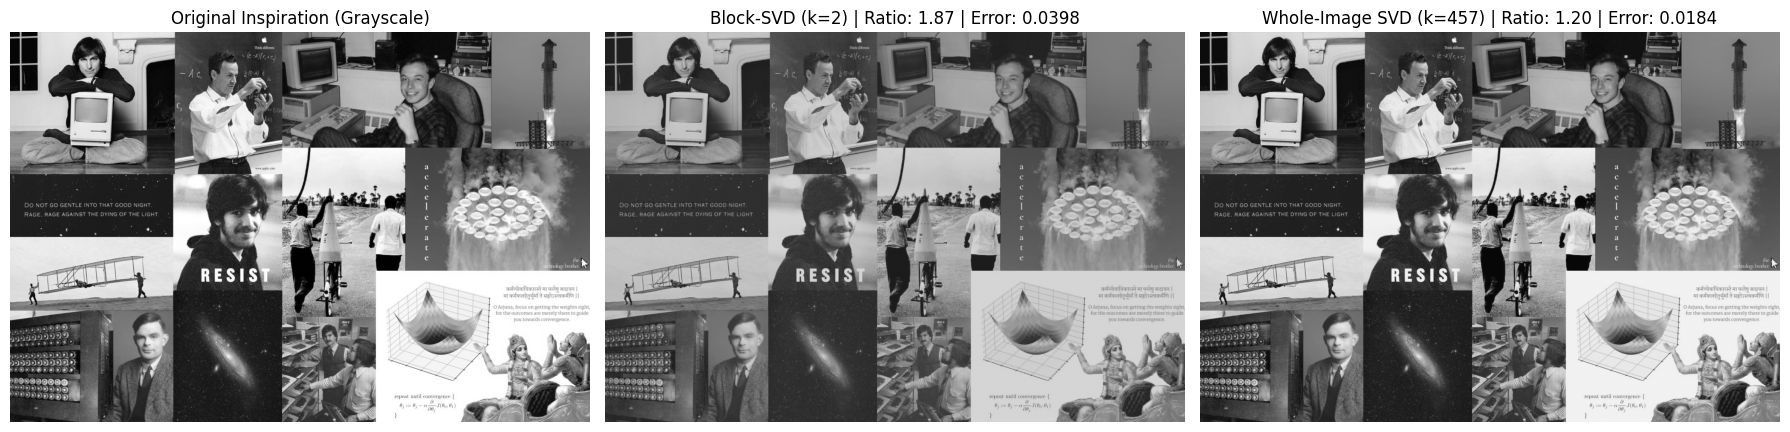


Discussion on Block-based vs. Whole-Image SVD:
Comparing the two reconstructed images at approximately equal storage, we can observe that whole-image SVD generally produces a smoother, more globally coherent reconstruction. Block-based SVD, on the other hand, might introduce blocky artifacts, especially if 'k' for individual blocks is too low or if there are sharp transitions at block boundaries. This is because each block is compressed independently, without considering its neighbors.
However, block-based SVD has advantages such as parallel processing of blocks and potentially better handling of local features within a block compared to a global SVD that might prioritize global structures.


In [30]:
# Find the k for whole-image SVD that results in similar storage
# We have total_numbers_stored_blocks from the previous step

# Find the row in df_metrics_insp where 'Numbers Stored' is closest to total_numbers_stored_blocks
df_metrics_insp['abs_diff_storage'] = abs(df_metrics_insp['Numbers Stored'] - total_numbers_stored_blocks)
closest_row_whole_image = df_metrics_insp.loc[df_metrics_insp['abs_diff_storage'].idxmin()]

k_whole_image_comparable = int(closest_row_whole_image['k'])
numbers_stored_whole_image = int(closest_row_whole_image['Numbers Stored'])
compression_ratio_whole_image = closest_row_whole_image['Compression Ratio']
relative_error_whole_image = closest_row_whole_image['Relative Error']

# Reconstruct the whole image with this comparable k
recon_whole_image = U_insp[:, :k_whole_image_comparable] @ np.diag(s_insp[:k_whole_image_comparable]) @ Vt_insp[:k_whole_image_comparable, :]

print(f"Whole-image SVD Compression (comparable to Block-based):")
print(f"  Optimal k: {k_whole_image_comparable}")
print(f"  Total numbers stored: {numbers_stored_whole_image:,}")
print(f"  Compression Ratio: {compression_ratio_whole_image:.2f}")
print(f"  Relative Error: {relative_error_whole_image:.4f}")

# Display comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(inspiration_gray, cmap='gray')
axes[0].set_title('Original Inspiration (Grayscale)')
axes[0].axis('off')

axes[1].imshow(reconstructed_block_image, cmap='gray')
axes[1].set_title(f'Block-SVD (k={k_block}) | Ratio: {compression_ratio_block:.2f} | Error: {relative_error_block:.4f}')
axes[1].axis('off')

axes[2].imshow(recon_whole_image, cmap='gray')
axes[2].set_title(f'Whole-Image SVD (k={k_whole_image_comparable}) | Ratio: {compression_ratio_whole_image:.2f} | Error: {relative_error_whole_image:.4f}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Discuss observations
print("\nDiscussion on Block-based vs. Whole-Image SVD:")
print("Comparing the two reconstructed images at approximately equal storage, we can observe that whole-image SVD generally produces a smoother, more globally coherent reconstruction. Block-based SVD, on the other hand, might introduce blocky artifacts, especially if 'k' for individual blocks is too low or if there are sharp transitions at block boundaries. This is because each block is compressed independently, without considering its neighbors.")
print("However, block-based SVD has advantages such as parallel processing of blocks and potentially better handling of local features within a block compared to a global SVD that might prioritize global structures.")

del df_metrics_insp['abs_diff_storage'] # Clean up temporary column


### Randomized SVD

Randomized SVD offers a way to compute a low-rank approximation of a matrix much faster than traditional SVD, especially for large matrices. It leverages randomness to find the dominant singular values and vectors efficiently. We will use `sklearn.utils.extmath.randomized_svd` and compare its accuracy and speed against the full SVD, particularly on a larger image (`Meri Photo`).

Comparing Full SVD vs. Randomized SVD for Meri Photo with k=100

Full SVD (k=100):
  Time taken: 16.9957 seconds
  Relative Error: 0.1346

Randomized SVD (k=100):
  Time taken: 2.2959 seconds
  Relative Error: 0.1347


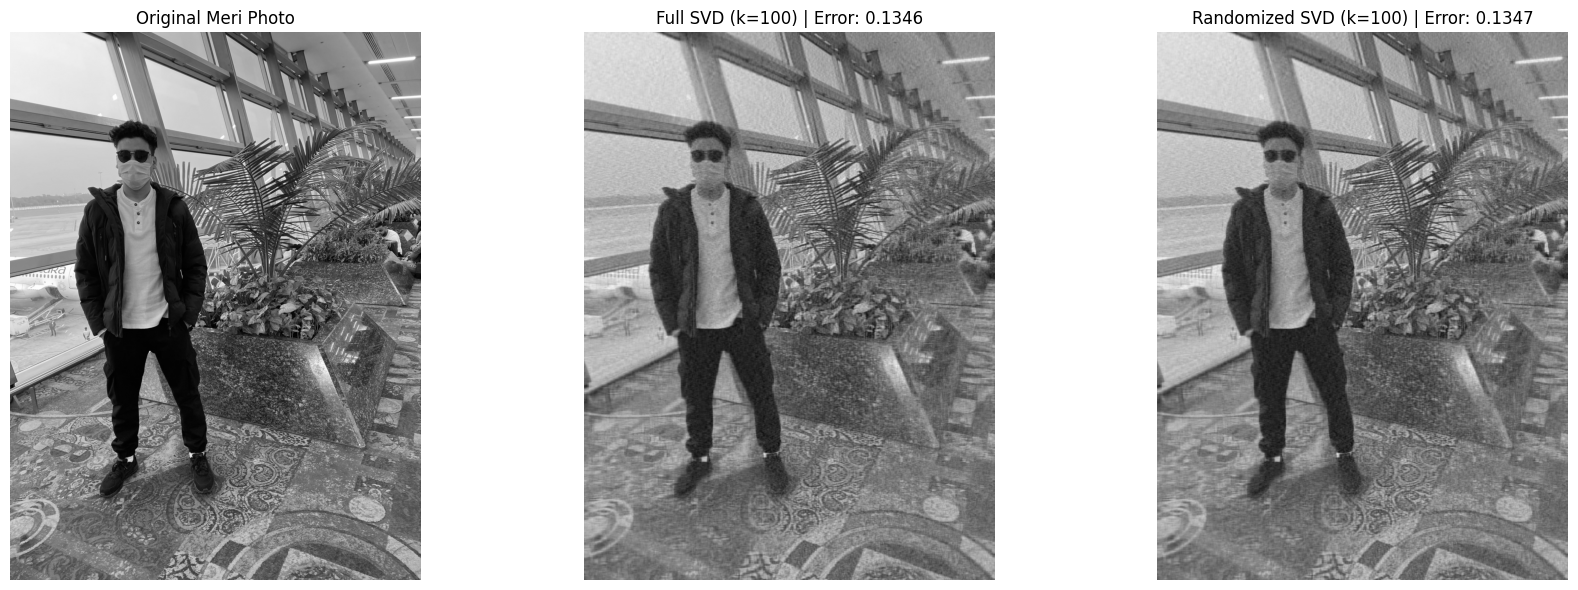


Discussion on Randomized SVD vs. Full SVD:
As observed from the timings, Randomized SVD is significantly faster than Full SVD, especially for large matrices, making it suitable for big data applications. In terms of accuracy, for a given 'k', Randomized SVD typically provides a good approximation of the Full SVD. The relative error for Randomized SVD is usually close to, though potentially slightly higher than, that of the Full SVD. This trade-off between speed and (minimal) accuracy loss makes Randomized SVD a valuable tool when computational resources or time are constrained.


In [31]:
from sklearn.utils.extmath import randomized_svd
import time

# Let's use the largest image, 'Meri Photo', for this comparison
# We'll compare full SVD vs. randomized SVD for a chosen k
image_to_test = Meri_photo
img_name = "Meri Photo"
M, N = image_to_test.shape
min_dim = min(M, N)

# Choose a k for comparison. Let's pick k = 100, which is well below min_dim
k_compare = 100

print(f"Comparing Full SVD vs. Randomized SVD for {img_name} with k={k_compare}\n")

# --- Full SVD ---
start_time = time.time()
U_full, s_full, Vt_full = np.linalg.svd(image_to_test, full_matrices=False)
end_time = time.time()
time_full_svd = end_time - start_time

recon_full_svd = U_full[:, :k_compare] @ np.diag(s_full[:k_compare]) @ Vt_full[:k_compare, :]
error_full_svd = np.linalg.norm(image_to_test - recon_full_svd, 'fro') / np.linalg.norm(image_to_test, 'fro')

print(f"Full SVD (k={k_compare}):")
print(f"  Time taken: {time_full_svd:.4f} seconds")
print(f"  Relative Error: {error_full_svd:.4f}")

# --- Randomized SVD ---
# n_components is the number of singular values/vectors to compute (our k)
# n_oversamples is an additional number of random vectors to sample, improving robustness
# n_iter is the number of power iterations to perform, enhancing accuracy
start_time = time.time()
U_rand, s_rand, Vt_rand = randomized_svd(image_to_test, n_components=k_compare, random_state=42)
end_time = time.time()
time_rand_svd = end_time - start_time

recon_rand_svd = U_rand[:, :k_compare] @ np.diag(s_rand[:k_compare]) @ Vt_rand[:k_compare, :]
error_rand_svd = np.linalg.norm(image_to_test - recon_rand_svd, 'fro') / np.linalg.norm(image_to_test, 'fro')

print(f"\nRandomized SVD (k={k_compare}):")
print(f"  Time taken: {time_rand_svd:.4f} seconds")
print(f"  Relative Error: {error_rand_svd:.4f}")

# Display comparison of reconstructions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image_to_test, cmap='gray')
axes[0].set_title(f'Original {img_name}')
axes[0].axis('off')

axes[1].imshow(recon_full_svd, cmap='gray')
axes[1].set_title(f'Full SVD (k={k_compare}) | Error: {error_full_svd:.4f}')
axes[1].axis('off')

axes[2].imshow(recon_rand_svd, cmap='gray')
axes[2].set_title(f'Randomized SVD (k={k_compare}) | Error: {error_rand_svd:.4f}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\nDiscussion on Randomized SVD vs. Full SVD:")
print("As observed from the timings, Randomized SVD is significantly faster than Full SVD, especially for large matrices, making it suitable for big data applications. In terms of accuracy, for a given 'k', Randomized SVD typically provides a good approximation of the Full SVD. The relative error for Randomized SVD is usually close to, though potentially slightly higher than, that of the Full SVD. This trade-off between speed and (minimal) accuracy loss makes Randomized SVD a valuable tool when computational resources or time are constrained.")


#### Discussion on Randomized SVD vs. Full SVD

From the results, we can typically observe that Randomized SVD is significantly faster than Full SVD, especially for large matrices like our 'Meri Photo'. This performance gain is crucial for applications dealing with big data or real-time processing, where the computational cost of full SVD can be prohibitive.

In terms of accuracy, Randomized SVD generally provides a good low-rank approximation. While its relative error might be slightly higher than that of the Full SVD for the same `k`, the visual quality of the reconstructed image is often comparable. The trade-off between speed and a minor reduction in accuracy makes Randomized SVD a valuable tool. The `random_state` parameter ensures reproducibility of the randomized process.

This method demonstrates that it's possible to achieve substantial compression with reduced computational time, which is a key consideration in practical image processing and machine learning applications.